# Phân tích dữ liệu bệnh tiểu đường trên người Pima Indians

## 1. Định nghĩa vấn đề
+ **Mô tả**:
    + Bộ dữ liệu Pima Indians Diabetes Database được phát triển bởi National Institute of Diabetes and Digestive and Kidney Diseases, nhằm hỗ trợ các nghiên cứu y học trong việc dự đoán khả năng mắc bệnh tiểu đường ở phụ nữ người Pima Indian (Arizona, Mỹ).
    + Tất cả bệnh nhân được chẩn đoán là phụ nữ người Pima Indian trên 21 tuổi.
+ **Dữ liệu đầu vào**:
    + Số lần mang thai
    + Nồng độ glucose huyết tương sau 2 giờ
    + Huyết áp tâm trương (mm Hg)
    + Độ dày nếp gấp da (mm)
    + Nồng độ insulin huyết thanh sau 2 giờ (mu U/ml)
    + Chỉ số khối cơ thể (kg/(m)^2)
    + Hàm phả hệ tiểu đường
    + Tuổi
+ **Kết quả**: class (1: Bị bệnh, 0: Không bị bệnh)

## 2. Chuẩn bị vấn đề

### 2.1. Import các thư viện cần thiết

In [728]:
# Load libraries
import os, sys
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix

import warnings

## 3. Lấy dữ liệu từ dataset.

Các cột dữ liệu bao gồm:
1. n_preg: Số lần mang thai
2. plasma_glu: Nồng độ glucose huyết tương sau 2 giờ
3. bld_press: Huyết áp tâm trương
4. sk_fd_th: Độ dày nếp gấp da
5. serum_ins: Nồng độ insulin huyết thanh sau 2 giờ
6. bmi: Chỉ số khối cơ thể
7. dia_ped_func: Hàm phả hệ tiểu đường
8. age: Tuổi
9. class: Mắc bệnh


In [729]:
columns = ["n_preg", "plasma_glu", "bld_press", "sk_fd_th", "serum_ins", "bmi", "dia_ped_func", "age", "class"]
dataFrame = pd.read_csv("../data/pima-indians-diabetes.csv", header=None, names=columns) # Đọc file vào dataFrame

### 2.2. Kiểm tra dữ liệu dataset

In [730]:
dataFrame.head()

,n_preg,plasma_glu,bld_press,sk_fd_th,serum_ins,bmi,dia_ped_func,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,1,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Phân tích khai phá dữ liệu

### 3.1. Thống kê, mô tả

#### **(1)Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ Thông tin chung về dữ liệu

In [731]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   n_preg        768 non-null    int64  
 1   plasma_glu    768 non-null    int64  
 2   bld_press     768 non-null    int64  
 3   sk_fd_th      768 non-null    int64  
 4   serum_ins     768 non-null    int64  
 5   bmi           768 non-null    float64
 6   dia_ped_func  768 non-null    float64
 7   age           768 non-null    int64  
 8   class         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp
+ Giá trị 8 tính chất ở dạng số nguyên hoặc số thập phân.
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu để phân lớp ở cột class

#### **(2) Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.

In [732]:
containsNull = dataFrame.isnull().sum().any()
numOfDuplicates = dataFrame.duplicated().sum()

if containsNull:
    print("Các dòng null: ")
    display.display(dataFrame[dataFrame.isnull().any(axis=1)])
else: 
    print("Không có dòng null.")


if numOfDuplicates > 0:
    print("Số dòng trùng lặp: ", numOfDuplicates)
    print("Các dòng trùng lặp: ")
    display.display(dataFrame[dataFrame.duplicated()])
else:
    print("Không có dòng trùng lặp.")

Không có dòng null.
Không có dòng trùng lặp.


**Nhận xét**:
+ Không có dòng null hay dòng trùng lặp trong dữ liệu.

#### **(3) Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [733]:
dataFrame.describe()

,n_preg,plasma_glu,bld_press,sk_fd_th,serum_ins,bmi,dia_ped_func,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.201823,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.817369,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,1.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Nhận xét**:
+ **(1) n_preg — Số lần mang thai**
   + Trung bình: 3.85, dao động 0–17
   + Phân bố lệch phải: nhiều người mang thai ít lần, nhưng có vài người rất nhiều lần (outlier 17 lần).
   + Giá trị nhỏ nhất là 0 (hợp lý — có thể là người chưa mang thai).

+ **(2) plasma_glu — Nồng độ glucose**

   + Trung bình: 120.9, độ lệch chuẩn 31.97
   + Min = 0, điều này không hợp lý về mặt sinh học (không thể có glucose = 0 mg/dl), có khả năng do giá trị bị thiếu.

+ **(3) bld_press — Huyết áp tâm trương**

   + Trung bình: 69.1 mmHg, độ lệch chuẩn 19.4
   + Min = 0, không thực tế (người sống không thể có huyết áp = 0), có khả năng do giá trị thiếu.

+ **(4) sk_fd_th — Độ dày nếp gấp da (Triceps skinfold)**

   + Trung bình: 20.5 mm, độ lệch chuẩn 15.95

   + Min = 0, không hợp lý, có khả năng do giá trị thiếu.

   + Khoảng 25% dữ liệu có giá trị bằng 0.

+ **(5) serum_ins — Nồng độ insulin huyết thanh**
   + Trung bình: 79.8, độ lệch chuẩn rất lớn (115.2)
   + Min = 0, không hợp lý, có khả năng do giá trị thiếu.
   + Có outlier rất cao (max = 846).

+ **(6) bmi — Chỉ số khối cơ thể**
   + Trung bình: 32.0, lệch chuẩn 7.88
   + Min = 0, không hợp lý (chỉ số BMI không thể bằng 0), có khả năng do giá trị thiếu.

+ **(7) dia_ped_func — Hàm phả hệ tiểu đường**
   + Trung bình: 0.47, lệch chuẩn 0.33
   + Min = 0.078, max = 2.42
   + Không có giá trị 0, phân bố hợp lý, do đó không có missing.

+ **(8) age — Tuổi**
   + Trung bình: 33.2 tuổi, lệch chuẩn 11.8
   + Min = 1 (bất thường — có thể dữ liệu sai hoặc nhập lỗi, vì đối tượng > 21 tuổi)
   + Max = 81, hợp lý.



#### **(4) Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class)**

Đối với bài toán phân lớp (classification problem), chúng ta cần tính số lần xuất hiện của thuộc tính phân lớp. Điều này là cần thiết cho vấn đề mất cân bằng (highly imbalanced problems) giữa các lớp nhằm cần xử lý đặc biệt trong bước chuẩn bị dữ liệu.

class
0    500
1    268
Name: count, dtype: int64


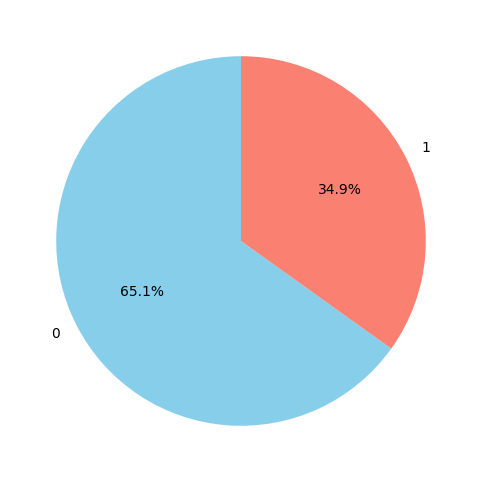

In [734]:
counts = dataFrame["class"].value_counts()
print(counts)
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.savefig("fig_dist.png")
plt.show()

**Nhận xét**:
+ Có 34.9% bệnh nhân bị chẩn đoán mắc tiểu đường.
+ Dữ liệu phân lớp mất cân bằng nhẹ (500:268).

### 3.2. Tiền xử lý dữ liệu

#### **(1) Đếm giá trị 0 ở một số tính chất**

In [735]:
zero_counts = (dataFrame == 0).sum()
print(zero_counts)

n_preg          111
plasma_glu        5
bld_press        35
sk_fd_th        227
serum_ins       374
bmi              11
dia_ped_func      0
age               0
class           500
dtype: int64


**Nhận xét**:
+ Tính chất plasma_glu, bld_press, sk_fd_th, serum_ins, bmi có phân bố 0 bất hợp lý nên cần được xử lý.
+ Tính chất sk_fd_th, serum_ins chứa nhiều giá trị 0 nên có thể cần được xử lý riêng.

##### **(2) Đưa tất cả giá trị 0 của các tính chất về null**

In [736]:
replacedColumns = ["plasma_glu", "bld_press", "bmi"]
dataFrame[replacedColumns] = dataFrame[replacedColumns].replace(0, np.nan)

print("Zero counts: ")
zeroCounts = (dataFrame[replacedColumns] == 0).sum()
print(zeroCounts)
print("\nNull counts: ")
nullCounts = (dataFrame[replacedColumns]).isna().sum()
print(nullCounts)

Zero counts: 
plasma_glu    0
bld_press     0
bmi           0
dtype: int64

Null counts: 
plasma_glu     5
bld_press     35
bmi           11
dtype: int64


**Nhận xét**:
+ Các tính chất ít giá trị 0 (plasma_glu, bld_press, bim có thể được điền vào bằng giá trị trung vị).

##### **(3) Xử lý các tính chất chứa giá trị null**
Điền giá trị trung vị của mỗi tính chất vào giá trị null.

In [737]:
for column in replacedColumns:
    dataFrame[column] = dataFrame[column].fillna(dataFrame[column].median())

nullCounts = (dataFrame[replacedColumns]).isna().sum()
print(nullCounts)

plasma_glu    0
bld_press     0
bmi           0
dtype: int64


##### **(4) Xử lý tính chất Age**
Đếm tổng số giá trị nhỏ hơn 21 trong Age

In [738]:
counts = (dataFrame["age"] < 21).sum()
print(counts)

1


##### **(5) Đưa giá trị không hợp lệ trong Age về null**

In [739]:
dataFrame.loc[dataFrame["age"] < 21, "age"] = np.nan
nullCounts = dataFrame["age"].isna().sum()
print("Null counts in Age:", nullCounts)

Null counts in Age: 1


##### **(6) Xử lý giá trị null trong Age**
Điền giá trị trung vị vào giá trị null.

In [746]:
dataFrame["age"] = dataFrame["age"].fillna(dataFrame["age"].median())

nullCounts = (dataFrame["age"]).isna().sum()
print(nullCounts)

0


### 3.3. Hiển thị dữ liệu

#### **(1) Hiển thị trên từng tính chất đơn (Univariate Plots)**

#### Biểu đồ Histogram

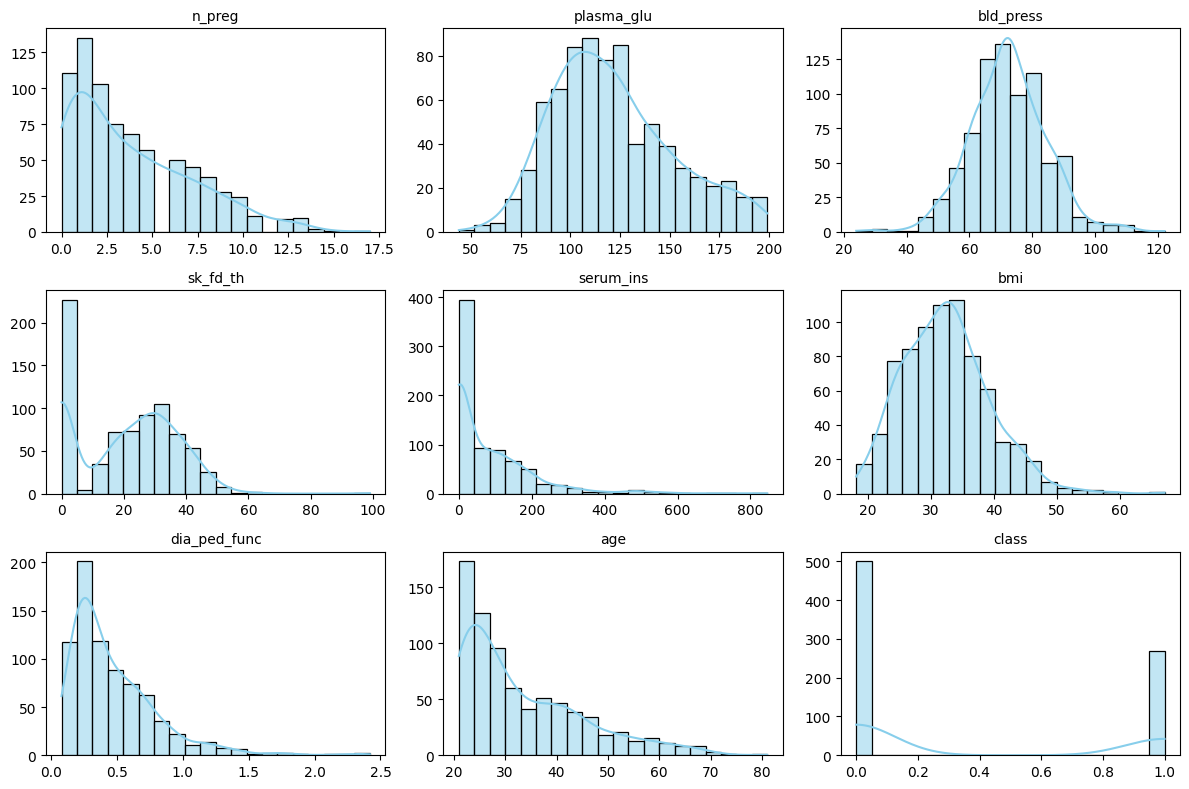

In [740]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(dataFrame.columns):
    sns.histplot(dataFrame[col], bins=20, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig("fig_hist.png")
plt.show()

##### Biểu đồ mật độ

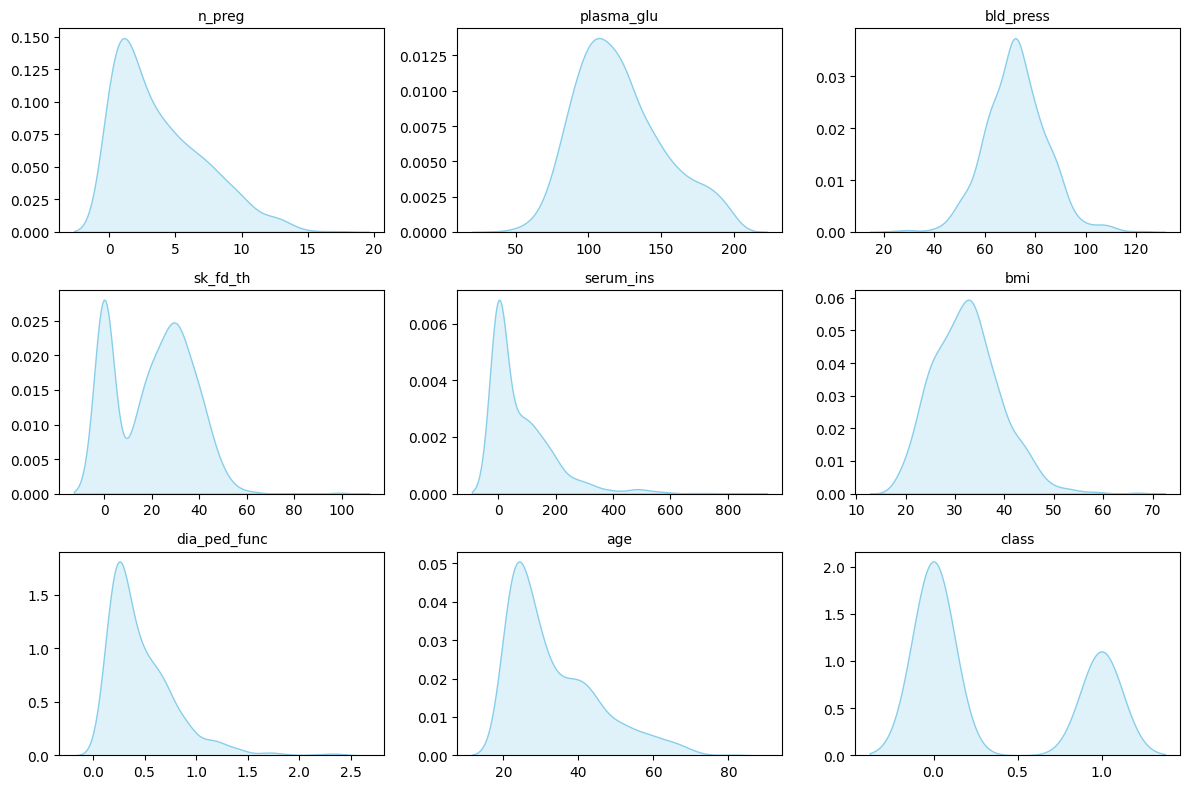

In [741]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(dataFrame.columns):
    sns.kdeplot(dataFrame[col], fill=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig("fig_dens.png")
plt.show()

##### Biểu đồ box plot

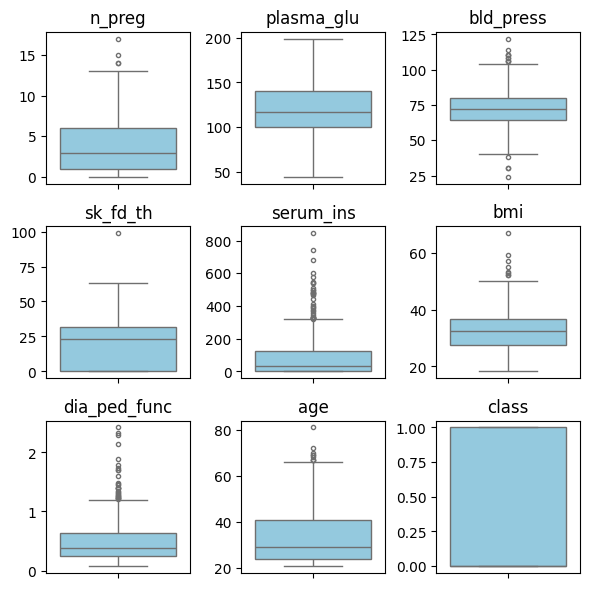

In [742]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()

for i, col in enumerate(dataFrame.columns):
    sns.boxplot(y=dataFrame[col], ax=axes[i], color="skyblue", fliersize=3, linewidth=1)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, 3 * 3):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box.png")
plt.show()

**Nhận xét**: 
+ Tính chất plasma_glu, bmi có dạng phân bố gần chuẩn.
+ Tính chất bld_press có dạng phân bố gần chuẩn nhưng có nhiều giá trị ngoại lai ở 0.
+ Tính chất age, n_preg, sk_fd_th lệch phải, cần được biến đổi.
+ Tính chất dia_ped_func, serum_ins lệch phải và có rất nhiều giá trị ngoại lai.

#### **(2) Hiển thị nhiều tính chất (Multivariate Plots)**

#### **Mối tương quan giữa các tính chất (Correlations)** 
Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

##### Dùng Heatmap

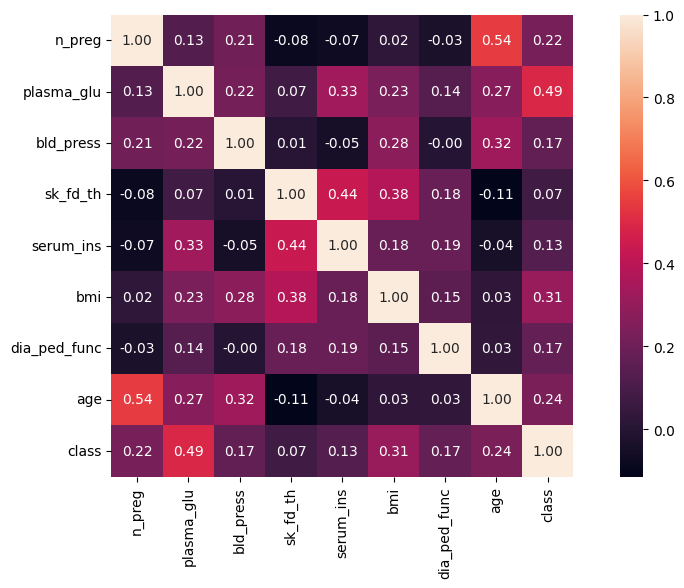

In [743]:
corrMat = dataFrame.corr()
plt.subplots(figsize=(12, 6))
sns.heatmap(corrMat, annot = True, fmt='.2f', annot_kws={'size': 10}, vmax=1.0, square=True)
plt.savefig("fig_corr.png")

##### Scatter Plot giữa 2 tính chất theo class

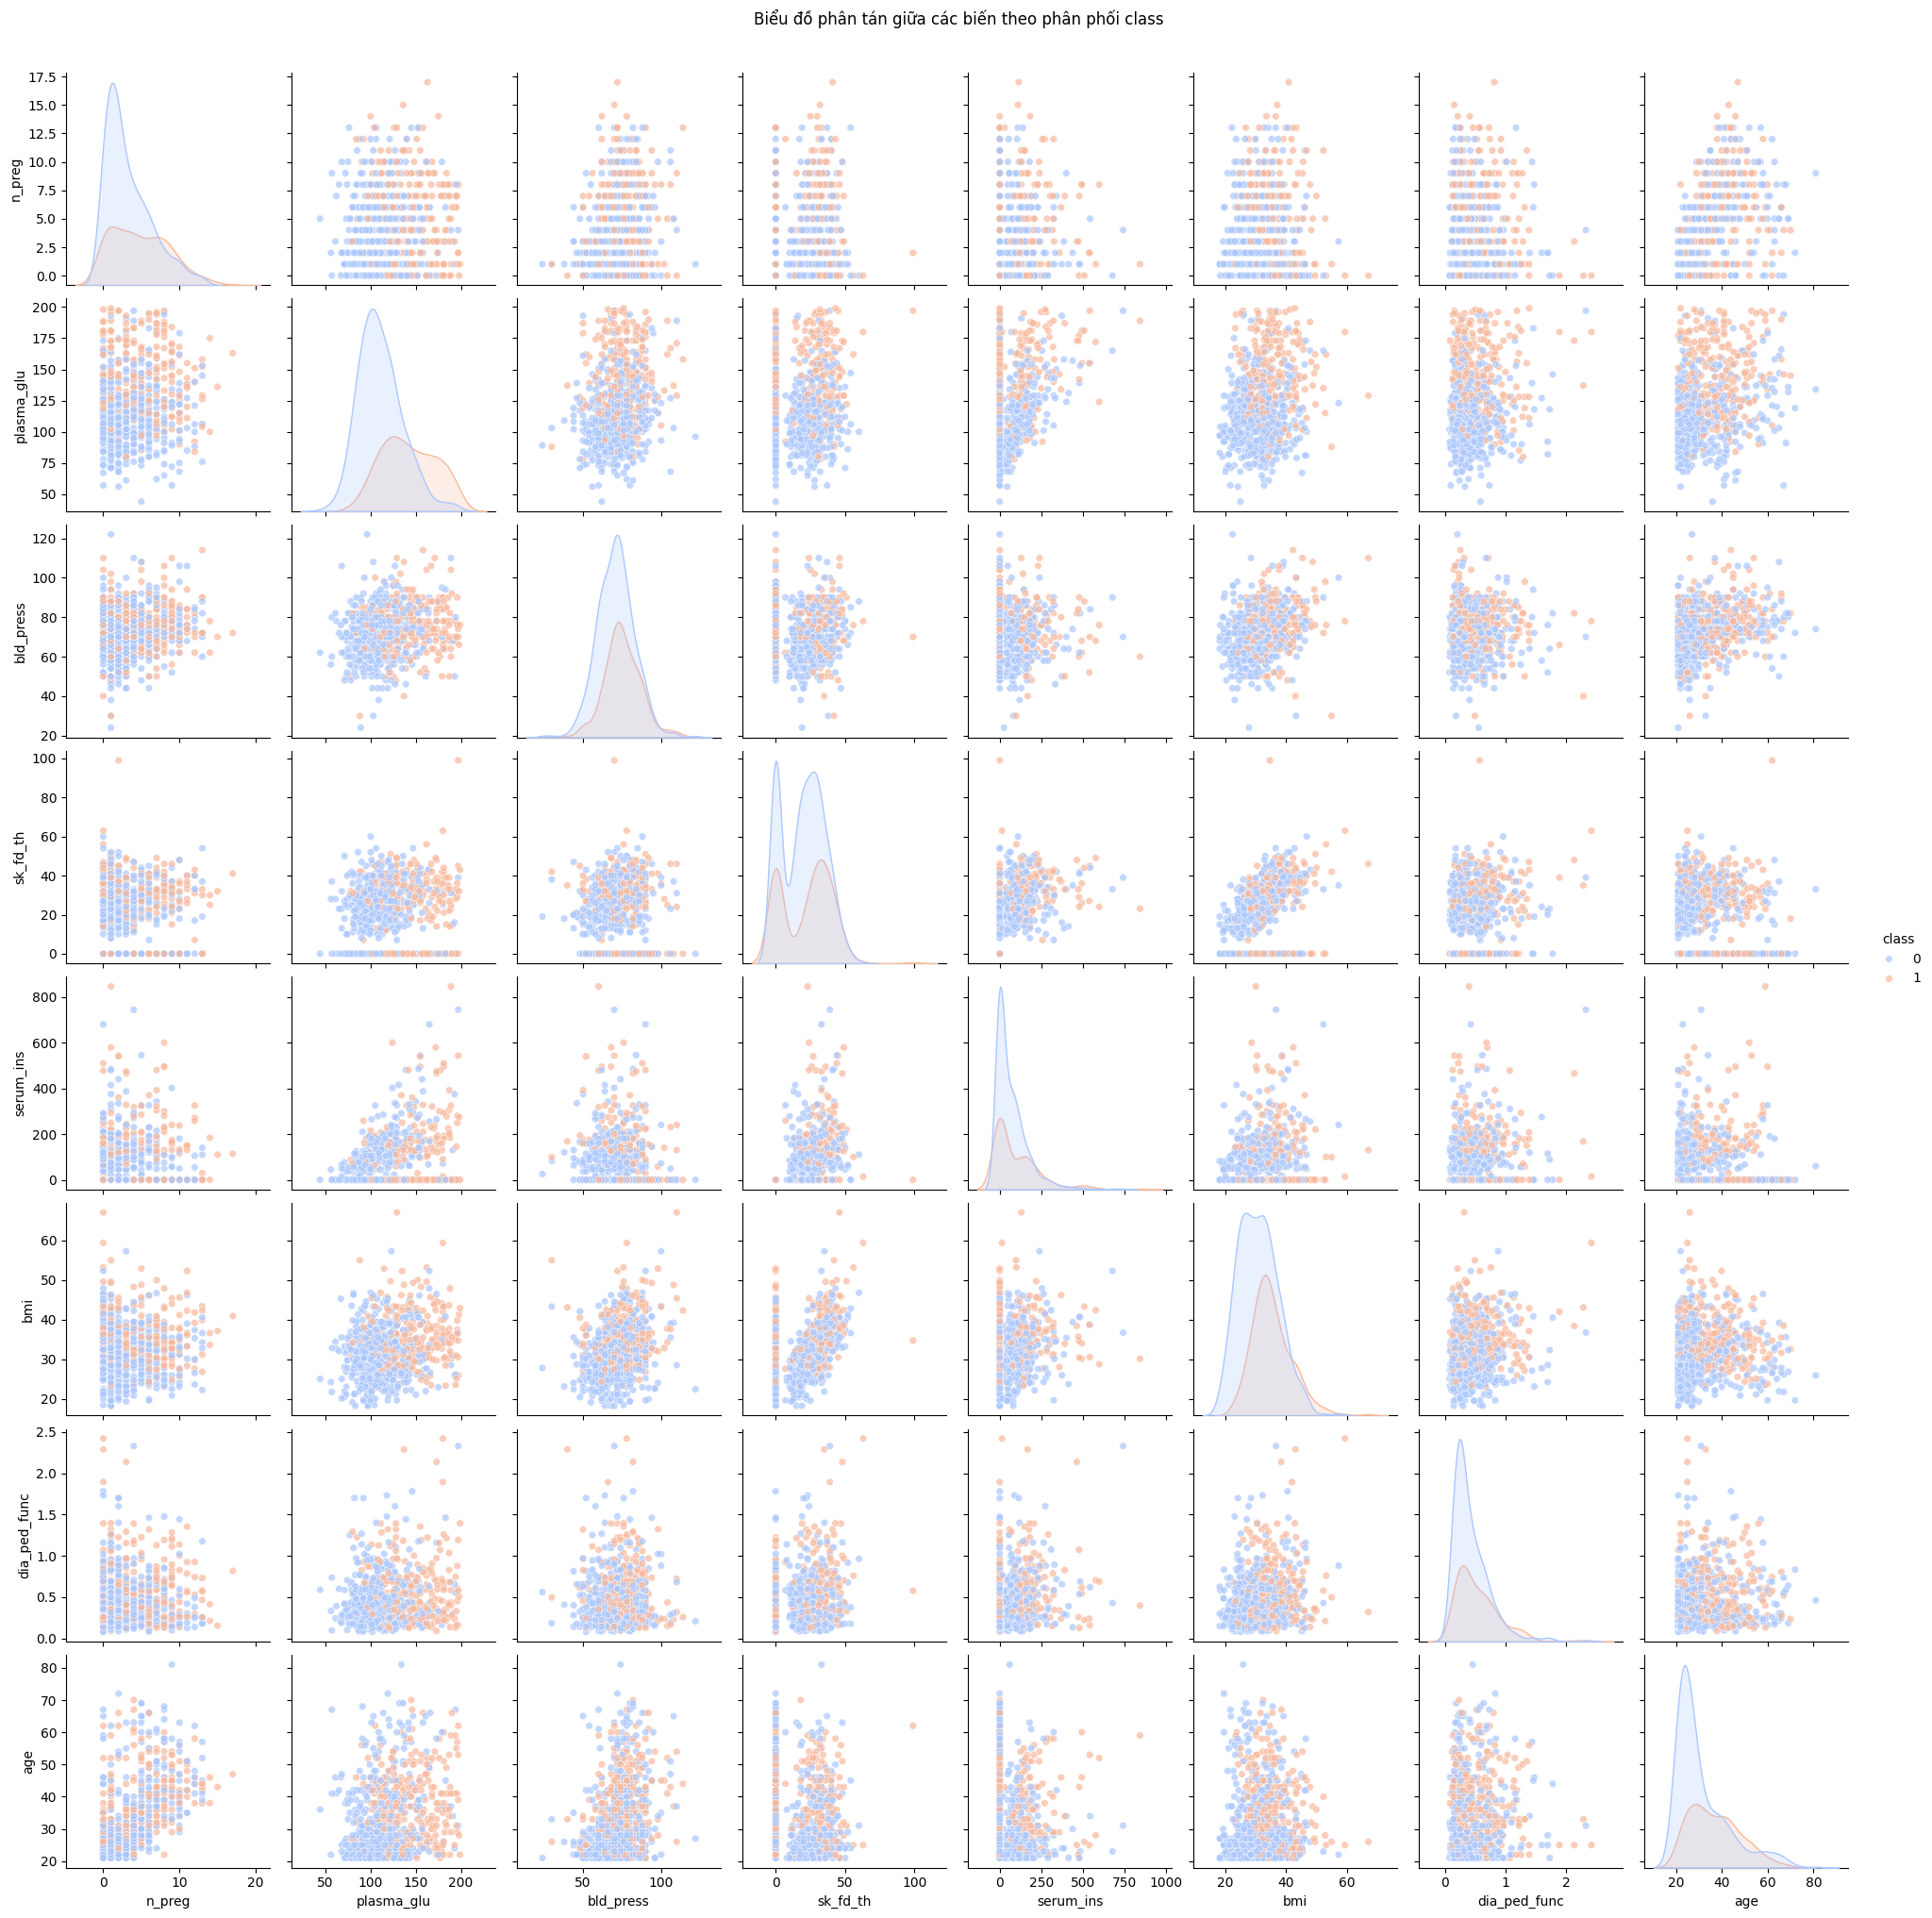

In [744]:

sns.pairplot(
    data=dataFrame,
    vars=[col for col in dataFrame.columns if col != 'class'],  
    hue='class',       
    palette='coolwarm',
    diag_kind='kde',     
    plot_kws={'alpha': 0.7, 's': 30}
)

plt.suptitle("Biểu đồ phân tán giữa các biến theo phân phối class", y=1.02)
plt.savefig("fig_scatter.png")
plt.show()

**Nhận xét**:
+ Tương quan giữa các tính chất với class:
   + plasma_glu (0.47): Mạnh nhất, cho thấy nồng độ glucose huyết tương có ảnh hưởng rõ rệt đến khả năng mắc tiểu đường.
   + bmi	(0.29): Cũng khá cao – chỉ số BMI cao làm tăng nguy cơ mắc bệnh.
   + age	(0.24): Người lớn tuổi có nguy cơ cao hơn.
   + n_preg (0.22): Phụ nữ mang thai nhiều lần có nguy cơ cao hơn.
   + dia_ped_func	(0.17): Tương quan yếu – chỉ ảnh hưởng nhẹ.
   + serum_ins, sk_fd_th, bld_press	(0.07–0.13): Gần như không đáng kể.
+ Tương quan giữa các tính chất độc lập (không phải class): 
   + age <-> n_preg (0.5445):	Tương quan khá cao, phụ nữ lớn tuổi thường có nhiều lần mang thai hơn.
   + sk_fd_th <-> serum_ins (0.4368): Có thể cùng phản ánh tình trạng chuyển hóa insulin.
   + sk_fd_th <-> bmi (0.3926): Hợp lý, vì độ dày da và chỉ số BMI đều phản ánh lượng mỡ cơ thể.
   + bmi <-> bld_press (0.2818): Người có BMI cao có xu hướng huyết áp cao.

# Kết thúc